In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

from transformers import (
    ViTImageProcessor, ViTForImageClassification,
    AutoTokenizer, AutoModelForSequenceClassification,
    GPT2LMHeadModel, GPT2Tokenizer,
    DetrImageProcessor, DetrForObjectDetection,
    pipeline
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

# ViT (Vision Transformer)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

minivan                   | 점수: 0.7514
beach wagon, station wagon, wagon, estate car, beach waggon, station waggon, waggon | 점수: 0.1754
jeep, landrover           | 점수: 0.0402
grille, radiator grille   | 점수: 0.0163
car wheel                 | 점수: 0.0035


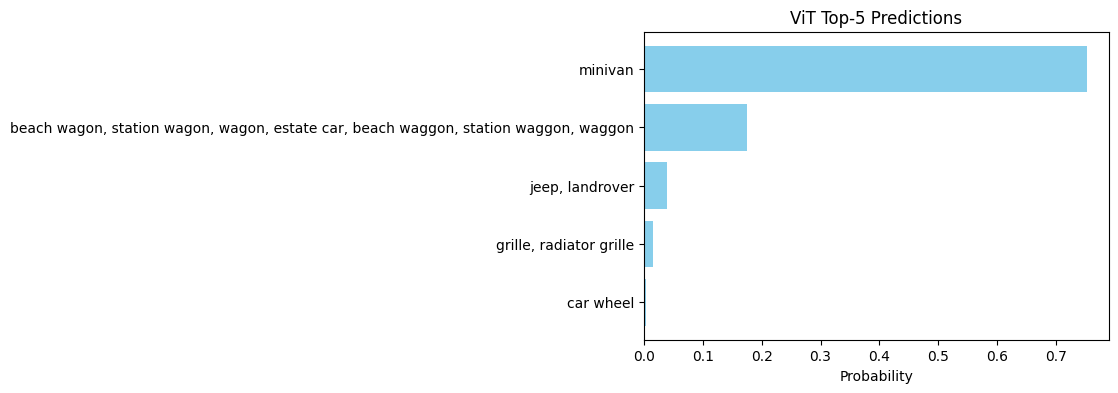

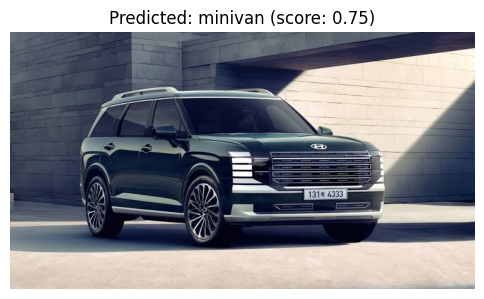

In [ ]:
model_name_vit = "google/vit-base-patch16-224"
processor_vit = ViTImageProcessor.from_pretrained(model_name_vit)
model_vit = ViTForImageClassification.from_pretrained(model_name_vit).to(device)

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS5Fc50THsgyRxFIeRYaQxF_hpiaTCTd1dtzl8N_B1xJIH6DELSC2UcQuZy&s=10"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor_vit(images=image, return_tensors="pt").to(device)
with torch.no_grad():
  outputs = model_vit(**inputs)

logits = outputs.logits
pred_prob = torch.nn.functional.softmax(logits, dim=1)
top5 = torch.topk(pred_prob, k=5)

# 4) 결과 확인 (Top-5)
labels_top5 = [model_vit.config.id2label[idx.item()] for idx in top5.indices[0]]
scores_top5 = [score.item() for score in top5.values[0]]
for label, score in zip(labels_top5, scores_top5):
  print(f"{label:25s} | 점수: {score:.4f}")

plt.figure(figsize=(6, 4))
plt.barh(labels_top5, scores_top5, color='skyblue')
plt.gca().invert_yaxis() # 위에서 아래로 높은 점수가 오도록
plt.xlabel("Probability")
plt.title("ViT Top-5 Predictions")
plt.show()

top1_label = labels_top5[0]
top1_score = scores_top5[0]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"Predicted: {top1_label} (score: {top1_score:.2f})")
plt.axis('off')
plt.show()

# BERT

In [ ]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm -rf ~/.cache/matplotlib
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== 감정 분석 결과 (별 1~5) ===

문장: 이 제품은 정말 최고야! 너무 마음에 들어.
결과: {'label': '5 stars', 'score': 0.9130706191062927}

문장: 솔직히 별로야. 돈이 아까움.
결과: {'label': '1 star', 'score': 0.42365762591362}

문장: Just okay, not too good, not too bad.
결과: {'label': '3 stars', 'score': 0.867607831954956}

문장: I absolutely love this! It's fantastic.
결과: {'label': '5 stars', 'score': 0.9735479354858398}

문장: Terrible experience. I hate it.
결과: {'label': '1 star', 'score': 0.8979193568229675}



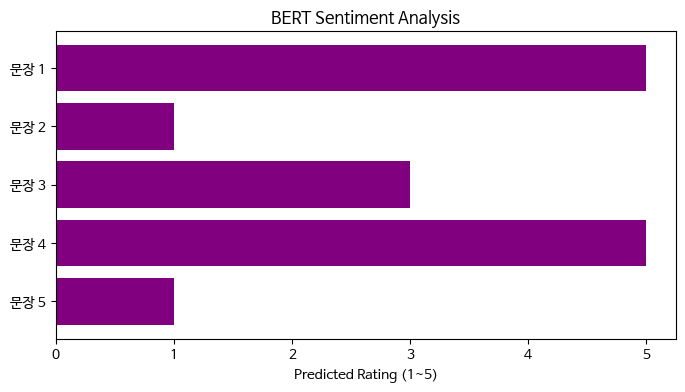

In [ ]:
model_name_bert = "nlptown/bert-base-multilingual-uncased-sentiment"
classifier_bert = pipeline("sentiment-analysis", model=model_name_bert, tokenizer=model_name_bert, device=0 if torch.cuda.is_available() else -1)

sentences = [
    "이 제품은 정말 최고야! 너무 마음에 들어.",
    "솔직히 별로야. 돈이 아까움.",
    "Just okay, not too good, not too bad.",
    "I absolutely love this! It's fantastic.",
    "Terrible experience. I hate it."
]

results = classifier_bert(sentences)

print("=== 감정 분석 결과 (별 1~5) ===\n")
for sentence, result in zip(sentences, results):
    print(f"문장: {sentence}")
    print(f"결과: {result}\n")
numeric_labels = [int(res['label'].split()[0]) for res in results] # '5 stars' -> 5

plt.figure(figsize=(8, 4))
plt.barh(range(len(sentences)), numeric_labels, color='purple')
plt.yticks(range(len(sentences)), [f"문장 {i+1}" for i in range(len(sentences))])
plt.xlabel('Predicted Rating (1~5)')
plt.title('BERT Sentiment Analysis')
plt.gca().invert_yaxis()
plt.show()

# GPT-2

In [ ]:
model_name_gpt2 = "gpt2"
gpt2_generator = pipeline(
    "text-generation",
    model=model_name_gpt2,
    tokenizer=model_name_gpt2,
    device=0 if torch.cuda.is_available() else -1
)

prompt = "Once upon a time," # 영어 예제

generated_texts = gpt2_generator(
    prompt,
    max_length=50,
    num_return_sequences=3,
    do_sample=True,
    top_k=50,
    top_p=0.95
)

for i, gen in enumerate(generated_texts):
  print(f"[생성 {i+1}] {gen['generated_text']}")
  print("-" * 80)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'top_p', 'top_k', 'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization

[생성 1] Once upon a time, one's life was in danger. When he was a child, he had to be in charge of his own life. He had to be a doctor, a teacher, a lawyer, a judge, a priest, and a writer, and he had to be a good man and a good friend and a good husband. But what he lacked in that, he made up for in that.

That's not to say that he wasn't a good man, but he was not as good a husband, either. He was a good man, and that was to say, he was a good man to be with. It was not a perfect marriage, but it was a perfect marriage.

I think there's a lot of people who believe that the human being is an ideal creature. They believe that human beings can be perfect. And what they're saying is that they should strive to be like that. I mean, it's hard to do this. I'm trying to do that.

And this is what I think is true about our society. It's that our society has been going on for over 400,000 years, and that if you take this back in the 60s and 70s, and we were talking about a world of absolute equ

# DETR

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


검출된 객체 수(임계값 0.7 이상): 2


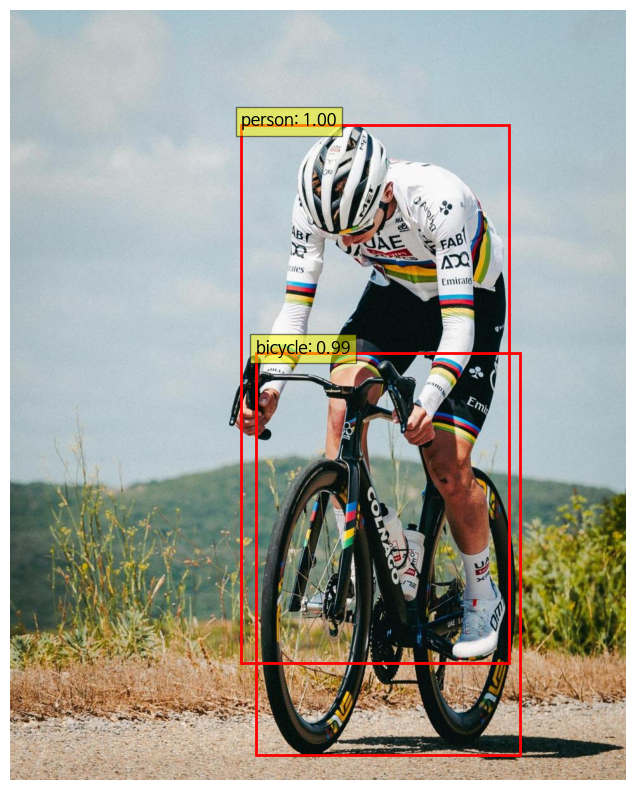

In [ ]:
model_name_detr = "facebook/detr-resnet-50"
processor_detr = DetrImageProcessor.from_pretrained(model_name_detr)
model_detr = DetrForObjectDetection.from_pretrained(model_name_detr).to(device)

url_detr = "https://cdn.road.cc/wp-content/uploads/roadcc/styles/main_width/public/photo-2025-07-21-19-13-5324.jpg" # 예시
image_detr = Image.open(requests.get(url_detr, stream=True).raw)

inputs_detr = processor_detr(images=image_detr, return_tensors="pt").to(device)
with torch.no_grad():
    outputs_detr = model_detr(**inputs_detr)

logits = outputs_detr.logits[0] # (num_queries, num_classes)
pred_boxes = outputs_detr.pred_boxes[0] # (num_queries, 4) -> center_x, center_y, w, h

probs = logits.softmax(-1)

probs_no_object = probs[..., :-1]

max_probs, class_ids = probs_no_object.max(dim=-1)

threshold = 0.7
keep = max_probs > threshold

boxes_to_plot = pred_boxes[keep]
scores_to_plot = max_probs[keep]
class_ids_to_plot = class_ids[keep]

print(f"검출된 객체 수(임계값 {threshold} 이상): {len(boxes_to_plot)}")

# 5) 시각화 (matplotlib)
plt.figure(figsize=(10, 10))
plt.imshow(image_detr)
ax = plt.gca()

img_w, img_h = image_detr.size
import matplotlib.patches as patches
for box, score, class_id in zip(boxes_to_plot, scores_to_plot, class_ids_to_plot):
  cx, cy, w, h = box
  # center_x, center_y, width, height -> x1, y1로 변환
  cx, cy, w, h = cx*img_w, cy*img_h, w*img_w, h*img_h
  x1 = cx - 0.5*w
  y1 = cy - 0.5*h

  rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none')
  ax.add_patch(rect)

  class_name = model_detr.config.id2label[class_id.item()]
  text = f"{class_name}: {score.item():.2f}"
  ax.text(x1, y1, text, fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))

plt.axis('off')
plt.show()

# 요약정리
- ViT: 이미지 분류 (인코더)
- BERT: 문장 분류 (인코더)
- GPT-2: 텍스트 생성 (디코더)
- DETR: 객체 검출 (인코더-디코더)